## 875. Koko Eating Bananas

Koko adora comer bananas. Existem `n` pilhas de bananas, onde a i-ésima pilha tem `piles[i]` bananas.
Os guardas foram embora e voltarão em `h` horas.

Koko pode escolher sua velocidade de comer bananas por hora `k`.
A cada hora, ela escolhe uma pilha e come `k` bananas dela.
Se a pilha tem menos de `k` bananas, ela come tudo e **não come mais nada nessa hora**.

Koko quer comer devagar, mas precisa terminar todas as bananas antes dos guardas voltarem.

**Retorne o menor inteiro `k`** tal que ela consiga comer todas as bananas dentro de `h` horas.

---

**Exemplo 1:**
```
Input:  piles = [3, 6, 7, 11], h = 8
Output: 4
```

**Exemplo 2:**
```
Input:  piles = [30, 11, 23, 4, 20], h = 5
Output: 30
```

**Exemplo 3:**
```
Input:  piles = [30, 11, 23, 4, 20], h = 6
Output: 23
```

**Constraints:**
- `1 <= piles.length <= 10^4`
- `piles.length <= h <= 10^9`
- `1 <= piles[i] <= 10^9`

---
## SPEC

**Input:**
- `piles: List[int]` — lista de pilhas de bananas (tamanhos variados)
- `h: int` — horas disponíveis antes dos guardas voltarem (`h >= len(piles)`)

**Output:**
- `int` — menor velocidade `k` (bananas/hora) tal que `total_hours(k) <= h`

**Função de custo para velocidade `k`:**
$$\text{total\_hours}(k) = \sum_{i} \left\lceil \frac{\text{piles}[i]}{k} \right\rceil$$

**Propriedade chave (monotonicidade):**
- Se `k` é viável → qualquer `k' > k` também é viável
- Se `k` não é viável → qualquer `k' < k` também não é viável
- ✅ Isso cria um espaço de busca **monotônico** → Binary Search aplicável

**Search space:**
- `lo = 1` (mínimo possível: comer 1 banana/hora)
- `hi = max(piles)` (máximo necessário: comer a maior pilha em 1 hora)

---
## PLAN

**Pattern:** Binary Search on the Answer

```
min_speed = 1, max_speed = max(piles)

while min_speed < max_speed:
    mid = (min_speed + max_speed) // 2    # candidate speed

    if can_finish(piles, mid, h):         # mid is feasible → try slower
        max_speed = mid
    else:                                 # mid too slow → need faster
        min_speed = mid + 1

return min_speed                          # smallest feasible speed
```

**`can_finish(piles, k, h)`:**
```
hours = sum(ceil(pile / k) for pile in piles)
return hours <= h
```

**Complexity:**
- Time:  O(n · log(max(piles)))  — binary search × cost function
- Space: O(1)

**Why `max_speed = mid` (not `mid - 1`) and `min_speed = mid + 1`?**
- We want the **leftmost valid** `k` → classic "find minimum feasible" binary search template
- When `mid` is feasible, it could be the answer itself, so we keep it: `max_speed = mid`
- When `mid` is not feasible, it's definitely wrong: `min_speed = mid + 1`

---
## IMPLEMENTATION

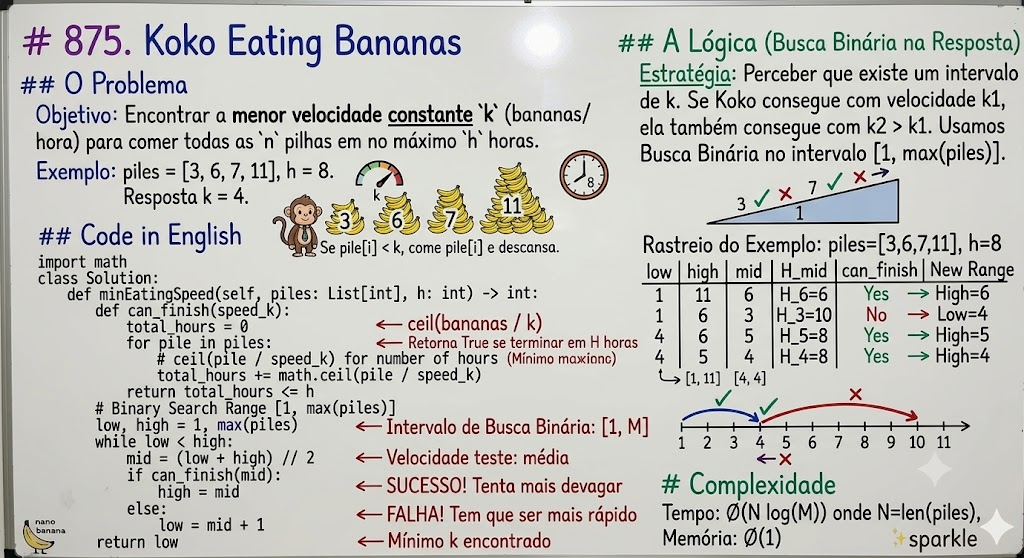

In [6]:
from math import ceil
from typing import List

def minEatingSpeed(piles: List[int], h: int) -> int:
    """
    Binary search on the answer.
    Find the minimum speed k in [1, max(piles)] such that
    total hours needed <= h.
    
    Time:  O(n * log(max(piles)))
    Space: O(1)
    """
    def hours_needed(speed_k: int) -> int:
        total = 0
        for pile in piles:
            # quantas horas para terminar essa pilha na velocidade speed_k?
            # ceil porque resto vira +1 hora (koko não come de outra pilha na mesma hora)
            total += ceil(pile / speed_k)
        return total

    # espaço de busca: velocidade mínima=1, máxima necessária=maior pilha
    min_speed, max_speed = 1, max(piles)

    # busca binária: encontrar a menor velocidade viável
    while min_speed < max_speed:
        mid = (min_speed + max_speed) // 2  # velocidade candidata

        if hours_needed(mid) <= h:
            max_speed = mid      # mid funciona, mas talvez velocidade menor também funcione
        else:
            min_speed = mid + 1  # mid é lento demais, precisa ser mais rápido

    # quando min_speed == max_speed, encontramos a menor velocidade viável
    return min_speed


# ── Testes ──────────────────────────────────────────────────────────────────
assert minEatingSpeed([3, 6, 7, 11], 8)        == 4
assert minEatingSpeed([30, 11, 23, 4, 20], 5)  == 30
assert minEatingSpeed([30, 11, 23, 4, 20], 6)  == 23
assert minEatingSpeed([1, 1, 1, 1], 4)          == 1
assert minEatingSpeed([1000000000], 1)          == 1000000000

print("piles=[3,6,7,11],       h=8  →", minEatingSpeed([3, 6, 7, 11], 8))
print("piles=[30,11,23,4,20],  h=5  →", minEatingSpeed([30, 11, 23, 4, 20], 5))
print("piles=[30,11,23,4,20],  h=6  →", minEatingSpeed([30, 11, 23, 4, 20], 6))
print("Todos os testes passaram ✓")

piles=[3,6,7,11],       h=8  → 4
piles=[30,11,23,4,20],  h=5  → 30
piles=[30,11,23,4,20],  h=6  → 23
Todos os testes passaram ✓
